# 03: Conformance assessment

Ports `build_conformance_voltvar.py` and `build_conformance_voltwatt.py` to DuckDB over the local store. 

Every AS/NZS 4777.2 expression is imported from `bms_sa_review.shared.as4777_curves` and runs unchanged

Three questions are kept separate:
1. **Maximum-output / required-Q conformance**: Did the inverter do what the curve asks?
2. **Whether the observation was informative** about an active response.
3. **Counterfactual-supported curtailed energy**: *not available yet*, needs D12.

The 10% site threshold is a project reporting convention, not a tolerance granted by AS/NZS 4777.2.

In [40]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_current, *_current.parents)
     if (p / "solar_edge").is_dir() and (p / "bms_sa_review").is_dir()),
    None,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd

from solar_edge.config import se_config as C
from solar_edge.lib import se_store, se_contract as contract, se_params
from solar_edge.lib import se_conformance as cf
from solar_edge.lib import se_adverse as adv
from solar_edge.lib import se_plots as plots

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

con = se_store.connect()
config = se_params.CONFIG
params = se_params.PARAMS
display(contract.manifest(config, params).query("section != 'convention'"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,section,setting,value
18,cohort,months,2025-01 .. 2025-12 (12 months)
19,cohort,interval_h,0.083333
20,cohort,phase_cohort,all
21,cohort,day_night,all
22,cohort,derating_selection,include
23,cohort,night_anomaly_selection,exclude
24,cohort,min_days_observed,0
25,cohort,max_capacity_kva,30.0
26,cohort,min_site_intervals,1
27,basis,rating_basis,s_99


## 1. Volt-VAr conformance (D9)

Interval scoring follows the CTE chain of `build_conformance_voltvar.build_sql`:
required Q → ±4% tolerance band → Figure 2.1 capability clamp → `Q_impact` → five categories.

Two departures, both forced and both in the manifest:

- **Capacity basis is `s_99`**, not nameplate. It scales the required-Q curve, the tolerance band, the 20% assessability rule and the capability floor. Because `s_99` is an *observed* p99, a site that never approached its inverter limit gets a low `s_99`, and a smaller required Q
- **`capability_profile="review_corrected"`**: Reactive-power priority above 0.8·S, and intervals below 0.2·S marked unassessable rather than scored, since Figure 2.1 sets no quantified minimum there.

BMS update: `reduced_nonconf` = adverse + inactive + significant shortfall. `Q_near_conformant` is excluded: those inverters deliver 90–110% of required reactive power.

In [41]:
vvar_site_day = cf.voltvar_site_day(con, config, params)
print(f"{len(vvar_site_day):,} site-days scored")

vvar_summary = cf.voltvar_summary(vvar_site_day, by_cohort=True)
display(vvar_summary.T)

560,087 site-days scored


,0,1
cohort,single-phase,three-phase
n_sites,1165,415
all_intervals,61526522,23763800
exposed_intervals,44501999,16732635
pct_exposed_of_all,72.33,70.412
capability_assessable_intervals,37563447,13133840
pct_assessable_of_exposed,84.408,78.492
Q_adverse_intervals,22932811,128502
Q_adverse_pct,61.051,0.978
Q_inactive_intervals,1395358,76216


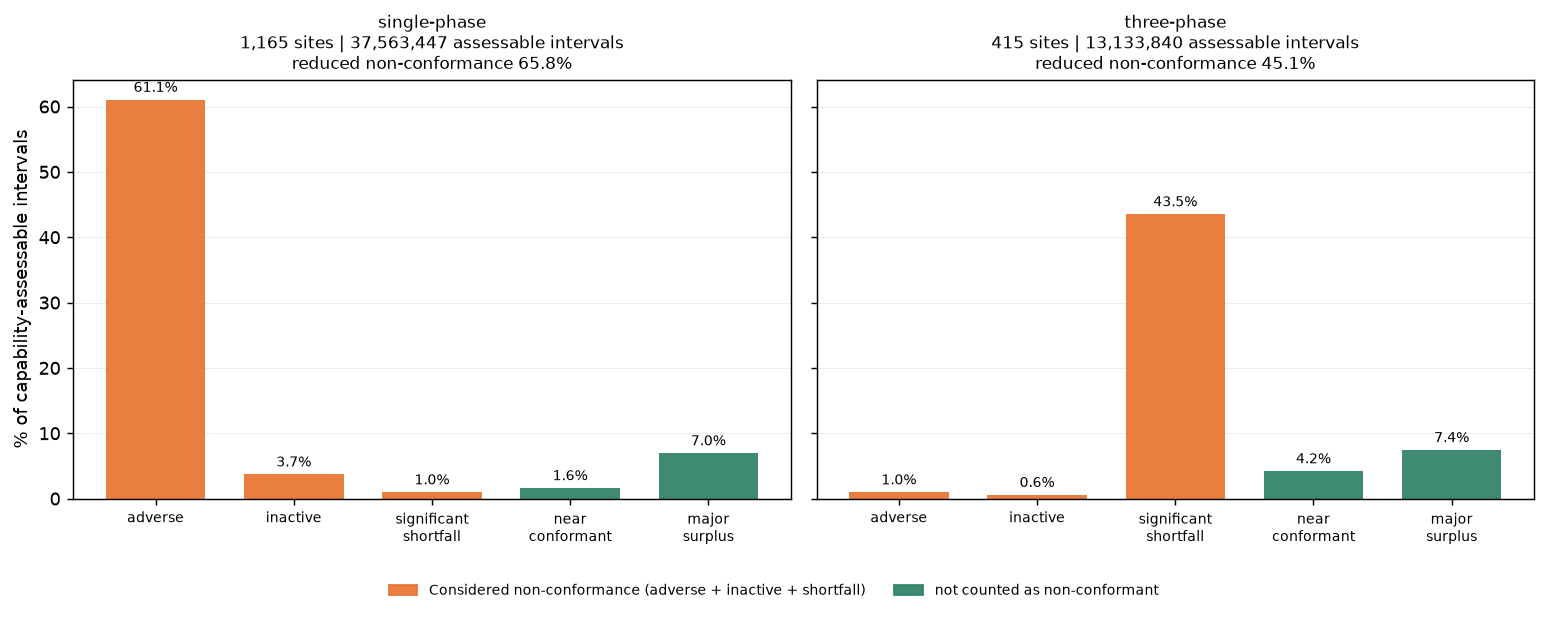

In [42]:
display(plots.plot_q_categories(vvar_summary))

### Same result unpacked:

| Measure | Denominator | Answers |
|---|---|---|
| **% of assessable intervals** | every interval counts once | how *often* it happens |
| **% of sites** | every site counts once, 10% rule per category | how *many inverters* |
| **kVArh** | none — an absolute total | how much reactive support was *actually missing* |
| **kVArh / kW / h** | site rating × assessable hours | how *badly*, per inverter, per hour |

The kVArh figure is Hossein's `sum(Q_adverse)` — the per-interval distance
`least(|Q − Q_min|, |Q − Q_max|)` in kvar — converted from kvar-intervals to energy by
multiplying by `INTERVAL_H` (5 min = 1/12 h).

In `kVArh/kW/h` the interval length appears in both numerator and denominator and
cancels, so it reduces to the **mean per-unit shortfall over assessable intervals**:
0.111 means single-phase sites sat, on average, 0.111 pu-kvar outside their allowed
band, every hour they were assessable.

The rows disagree, and that is the point. Read them against each other.

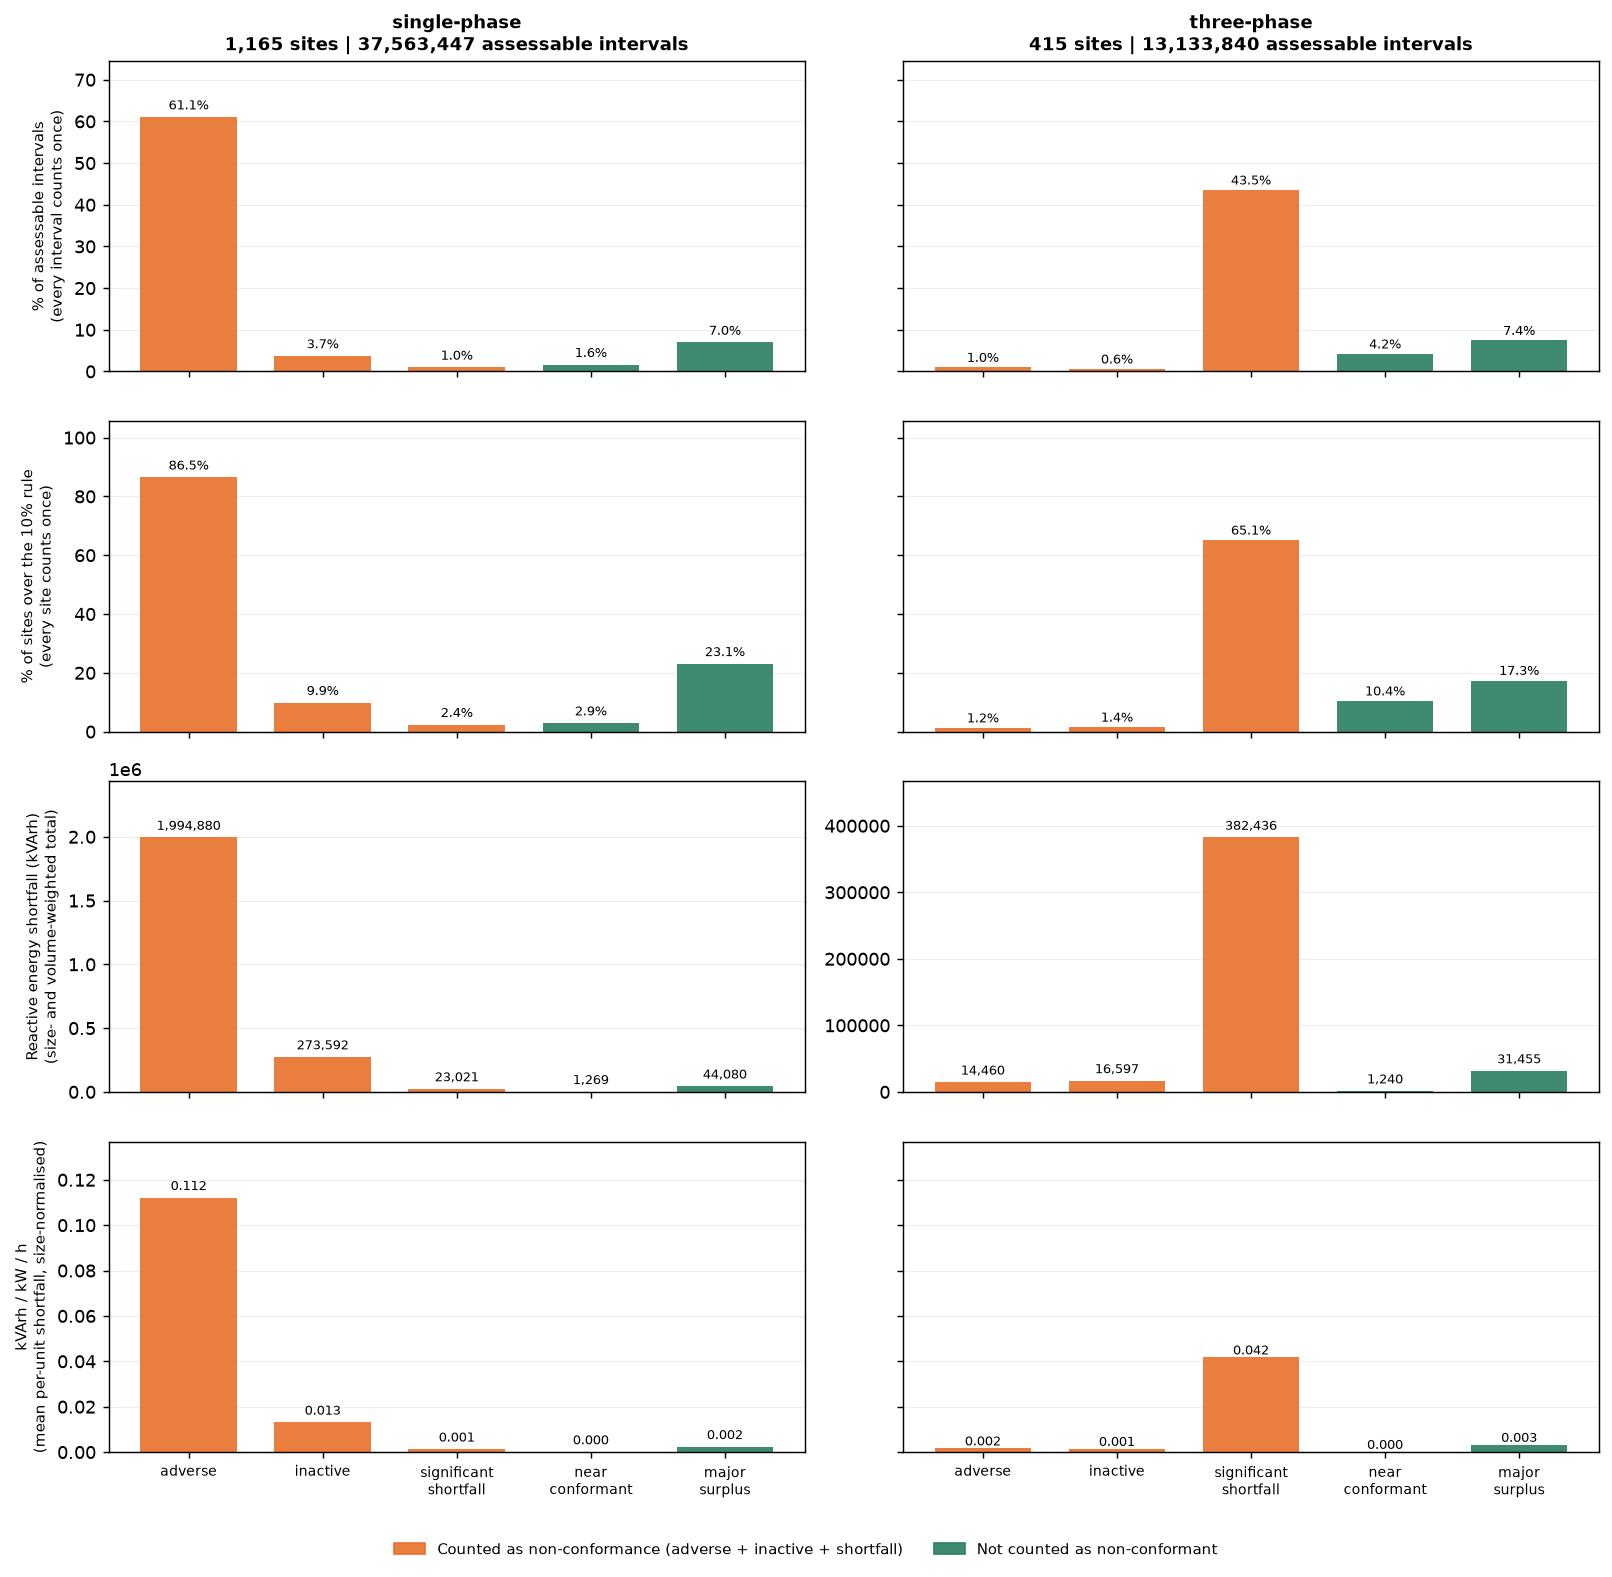

,cohort,category,n_sites,assessable_intervals,pct_intervals,pct_sites,kvarh,kvarh_per_kw_per_h
0,single-phase,Q_adverse,1165,37563447,61.051,86.524,1994880.38,0.11212
1,single-phase,Q_inactive,1165,37563447,3.715,9.871,273591.54,0.01312
2,single-phase,Q_significant_shortfall,1165,37563447,0.984,2.403,23021.00,0.00127
3,single-phase,Q_near_conformant,1165,37563447,1.619,2.918,1269.03,0.00006
4,single-phase,Q_major_surplus,1165,37563447,6.958,23.090,44080.36,0.00237
5,three-phase,Q_adverse,415,13133840,0.978,1.205,14460.03,0.00167
6,three-phase,Q_inactive,415,13133840,0.580,1.446,16596.94,0.00146
7,three-phase,Q_significant_shortfall,415,13133840,43.540,65.060,382435.58,0.04177
8,three-phase,Q_near_conformant,415,13133840,4.211,10.361,1239.76,0.00014
9,three-phase,Q_major_surplus,415,13133840,7.444,17.349,31455.33,0.00324


In [43]:
vvar_measures = cf.voltvar_measures(vvar_site_day, config)
display(plots.plot_conformance_dashboard(vvar_measures))
display(vvar_measures)

## 2. Volt-VAr site verdicts

**The 10% rule, exactly as Solar Analytics applies it** (`conformance_metrics.aggregate_sites`):

```
nonconf_frac = reduced_nonconf_count / capability_assessable_count
conformant   = nonconf_frac <  0.10      # STRICTLY less than
nonconformant= nonconf_frac >= 0.10
```

Two details that matter:

- The denominator is **capability-assessable intervals**, not all intervals and not
  voltage-exposed intervals. Below 0.2·S the standard sets no quantified requirement.
- The comparison is **strict**. A site sitting exactly on 0.10 is non-conformant.

It is a project reporting convention, not a tolerance granted by AS/NZS 4777.2.

Sites with no assessable intervals get **"not assessable"**, never "conformant" —
scoring an unobserved site as passing turns a conformance rate into a coverage measure.
Note this differs slightly from the Solar Analytics function, which *drops* such sites
before computing the percentage; here they are visible in the table and can be excluded
explicitly.

In [44]:
vvar_verdicts = cf.voltvar_site_verdicts(vvar_site_day, config)
display(pd.crosstab(
    vvar_verdicts.is_three_phase.map({False: "single-phase", True: "three-phase"}),
    vvar_verdicts.verdict, normalize="index").round(4) * 100)
display(pd.crosstab(
    vvar_verdicts.is_three_phase.map({False: "single-phase", True: "three-phase"}),
    vvar_verdicts.verdict, margins=True))

verdict,conformant,non-conformant
is_three_phase,,
single-phase,13.13,86.87
three-phase,33.98,66.02


verdict,conformant,non-conformant,All
is_three_phase,,,
single-phase,153,1012,1165
three-phase,141,274,415
All,294,1286,1580


### The verdict in the same four currencies

The category dashboard in section 1 splits non-conformance five ways. This collapses it
to the binary the reporting actually turns on — conformant vs non-conformant on the 10%
rule — and asks the same four questions of it.

Read rows 1 and 3 against each other. Non-conformant sites are a **majority by headcount
already**, but they hold essentially *all* of the missing kVArh: conformant sites
contribute 1,248 kVArh out of 838,123 single-phase, i.e. **0.15%**. That is what passing
the 10% rule means in energy terms — not "slightly worse", but "negligible".

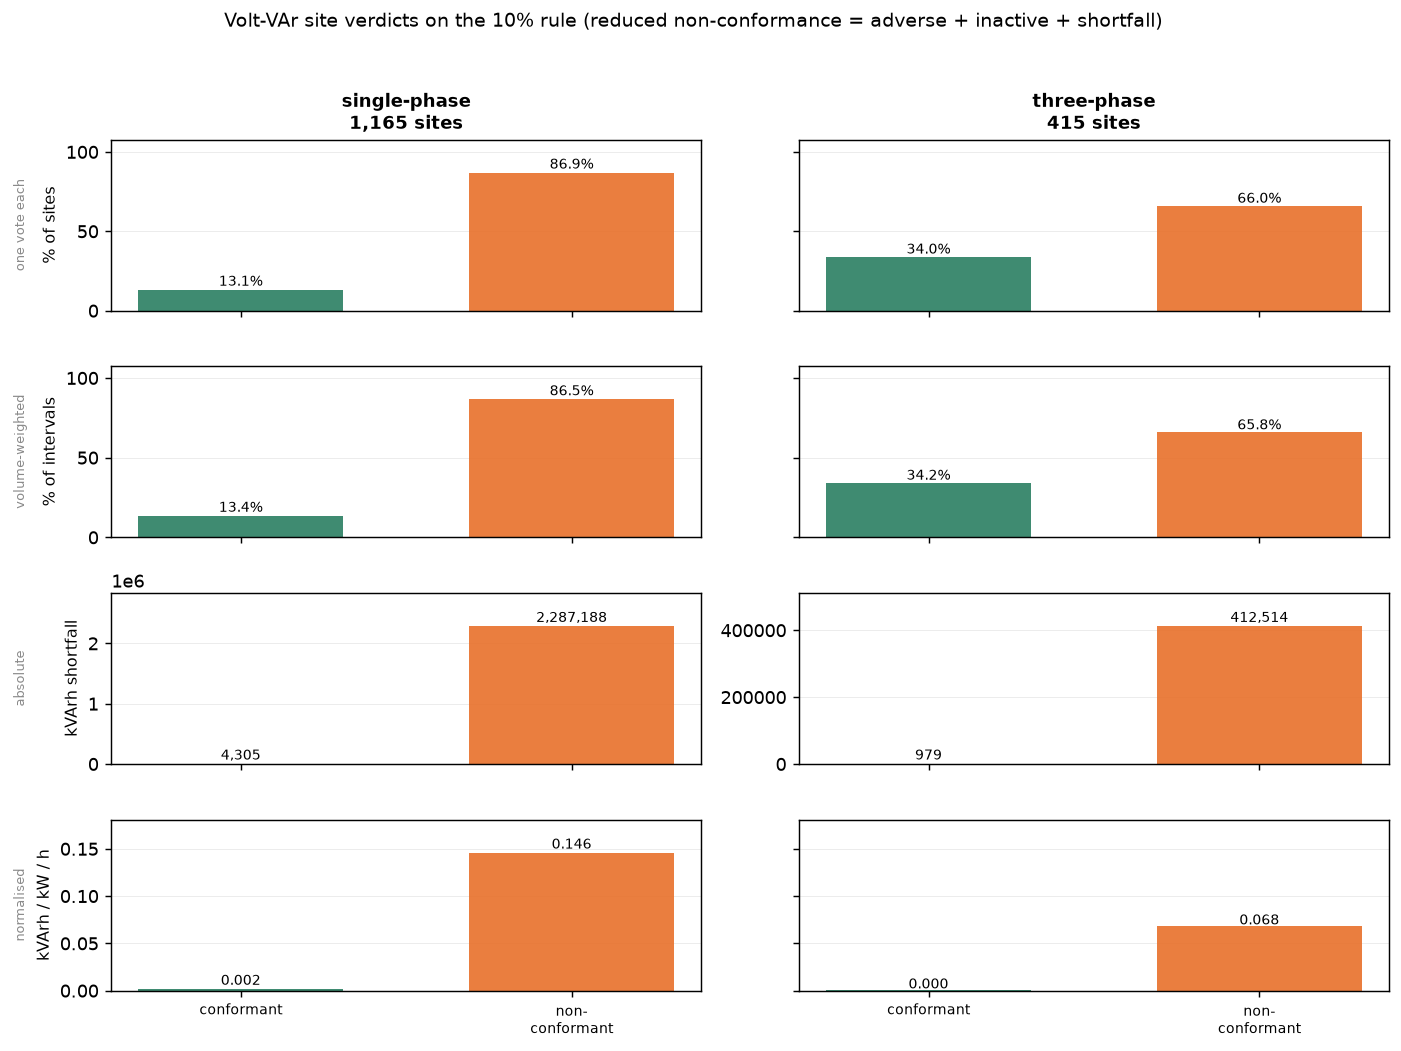

,cohort,verdict,n_sites,pct_sites,pct_intervals,kvarh,kvarh_per_kw_per_h
0,single-phase,conformant,153,13.133,13.450,4304.57,0.00184
1,single-phase,non-conformant,1012,86.867,86.550,2287188.35,0.14587
2,three-phase,conformant,141,33.976,34.186,978.63,0.00034
3,three-phase,non-conformant,274,66.024,65.814,412513.92,0.06804


In [45]:
vvar_verdict_measures = cf.site_verdict_measures(vvar_site_day, config)
display(plots.plot_site_verdicts(vvar_verdict_measures, config))
display(vvar_verdict_measures)

## 3. Volt-VAr breakdowns

Two views per dimension, deliberately kept apart because they have different
denominators and answer different questions:

- **`site_pct`** — % of *sites* conformant / non-conformant, on the 10% rule. Equal
  weight per site.
- **`interval_pct`** — % of capability-assessable *intervals* in each category.
  Weighted by how much each site was observed.

A group can look fine on one and poor on the other: a handful of heavily observed sites
can dominate the interval view while barely moving the site view. Reporting only one of
them hides that.

In [46]:
for dimension, label in [("site_state", "STATE"),
                         ("capacity_band", "SYSTEM SIZE (s_99, kVA)"),
                         ("cohort", "PHASE COHORT")]:
    site_pct, interval_pct = cf.voltvar_breakdown(con, vvar_site_day, by=dimension,
                                                  config=config)
    print(f"\n{'=' * 100}\n{label} — % of SITES by verdict (10% rule)\n{'=' * 100}")
    display(site_pct)
    print(f"{label} — % of ASSESSABLE INTERVALS by category")
    display(interval_pct)
    display(plots.plot_breakdown_rates(
        site_pct, interval_pct, dimension, "pct_reduced_nonconf",
        label=f"Volt-VAr — {label}"))


STATE — % of SITES by verdict (10% rule)


,site_state,n_sites,pct_sites_conformant,pct_sites_non_conformant
0,New South Wales,560,13.75,86.25
1,Queensland,452,34.07,65.93
2,South Australia,568,11.09,88.91


STATE — % of ASSESSABLE INTERVALS by category


,site_state,n_sites,assessable_intervals,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,pct_reduced_nonconf
2,South Australia,568,18591709.0,49.193,2.928,18.328,1.659,5.086,70.449
0,New South Wales,560,17161264.0,53.064,4.064,9.222,2.147,6.763,66.350
1,Queensland,452,14944314.0,32.179,1.538,7.347,3.242,9.939,41.064



SYSTEM SIZE (s_99, kVA) — % of SITES by verdict (10% rule)


...

,capacity_band,n_sites,assessable_intervals,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,pct_reduced_nonconf
0,<3,2,62276.0,34.223,0.000,0.000,4.048,31.704,34.223
1,3-4,15,487141.0,56.216,2.157,0.004,4.376,19.171,58.377
2,4-5,353,11173554.0,62.455,1.966,3.732,2.390,9.599,68.153
3,5-6,486,15847009.0,55.765,2.522,4.579,1.623,7.341,62.866
4,6-8,348,10993659.0,41.423,3.419,14.619,2.817,5.667,59.461
5,8-10,262,8449945.0,24.408,4.210,22.474,2.587,5.164,51.092
6,>10,114,3683703.0,9.074,2.992,39.065,2.301,4.973,51.132



PHASE COHORT — % of SITES by verdict (10% rule)


,cohort,n_sites,pct_sites_conformant,pct_sites_non_conformant
0,single-phase,1165,13.13,86.87
1,three-phase,415,33.98,66.02


PHASE COHORT — % of ASSESSABLE INTERVALS by category


,cohort,n_sites,assessable_intervals,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,pct_reduced_nonconf
0,single-phase,1165,37563447.0,61.051,3.715,0.984,1.619,6.958,65.750
1,three-phase,415,13133840.0,0.978,0.580,43.540,4.211,7.444,45.098


### By postcode

507 postcodes, so this is shown as the extremes rather than the full table. Small
postcodes carry very few sites — read `n_sites` before drawing any conclusion from a
rate.

In [47]:
pc_sites, pc_intervals = cf.voltvar_breakdown(con, vvar_site_day, by="postcode",
                                              config=config)
big = pc_intervals[pc_intervals.n_sites >= 5].copy()
print(f"{len(pc_intervals):,} postcodes; {len(big):,} with at least 5 sites\n")
print("Highest reduced non-conformance:")
display(big.nlargest(10, "pct_reduced_nonconf"))
print("Lowest:")
display(big.nsmallest(10, "pct_reduced_nonconf"))

pc_intervals.to_csv(C.ARTEFACT_DIR / "voltvar_by_postcode.csv", index=False)
pc_sites.to_csv(C.ARTEFACT_DIR / "voltvar_sites_by_postcode.csv", index=False)

504 postcodes; 98 with at least 5 sites

Highest reduced non-conformance:


,postcode,n_sites,assessable_intervals,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,pct_reduced_nonconf
172,2640,7,238484.0,75.161,10.024,13.436,0.030,0.324,98.620
102,2287,10,312666.0,62.578,34.955,0.000,0.143,1.097,97.532
98,2283,5,141508.0,81.110,15.721,0.000,0.099,1.136,96.831
426,5112,5,172470.0,55.400,6.599,32.333,0.395,1.675,94.331
448,5162,7,211385.0,77.869,2.754,12.060,0.439,1.563,92.683
429,5115,6,197081.0,90.248,0.065,0.000,0.461,5.465,90.313
122,2322,8,234750.0,77.719,0.134,11.300,0.682,3.376,89.153
121,2321,9,291721.0,60.250,18.133,8.756,0.278,2.221,87.139
367,5021,6,202164.0,40.583,14.505,32.032,0.827,0.273,87.120
393,5062,14,445080.0,37.419,3.474,46.040,0.668,1.669,86.932


Lowest:


,postcode,n_sites,assessable_intervals,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,pct_reduced_nonconf
320,4575,8,247692.0,8.417,0.000,4.505,5.243,8.473,12.921
294,4507,6,205780.0,14.074,0.669,0.026,3.213,9.382,14.769
303,4551,9,311441.0,19.062,0.024,0.010,7.358,15.286,19.095
241,4151,5,169835.0,12.777,0.000,9.811,8.010,9.674,22.588
318,4573,10,324593.0,25.567,0.011,0.176,3.632,20.696,25.754
82,2232,5,158904.0,26.405,0.102,0.041,8.798,13.874,26.548
301,4520,5,149565.0,27.793,0.739,0.003,0.583,2.140,28.534
302,4521,5,155402.0,3.339,0.107,25.393,3.490,10.899,28.839
204,4011,6,173565.0,19.670,0.000,11.712,5.021,6.791,31.382
296,4509,6,193122.0,26.902,0.001,5.237,3.816,16.146,32.139


## 4. Unpacking the adverse results

`Q_adverse` means the inverter moved reactive power in the **wrong direction** — supplying
where the curve requires absorption. Taken at face value that is a serious finding.

But it cannot be taken at face value, because roughly 106 sites are misoriented under the
current sign convention and will land here for a data-format reason.

The triage uses **magnitude**, which is orientation-independent:

| class | meaning | safe to report as non-conformance? |
|---|---|---|
| `polarity_suspect` | adverse in direction, but \|Q\| tracks the required curve within ±4% | **No** — a data-format finding |
| `genuinely_adverse` | adverse in direction, magnitude does not match the curve | **Yes** — adverse under either orientation |
| `adverse_but_inactive` | adverse in direction, delivering < 25% of requirement | **No** — direction of a near-zero quantity |
| `not_adverse` | absorbing, or near zero | — |

This is **triage, not a correction.** Flipping the polarity-suspect sites and re-scoring
would infer the sign from conformity with the curve and then report conformity with the
curve.

In [48]:
adverse = adv.classify_adverse_sites(con, config)
display(pd.crosstab(adverse.adverse_class, adverse.cohort, margins=True))
display(adv.adverse_summary(adverse))

cohort,single-phase,three-phase,All
adverse_class,,,
adverse_but_inactive,612,1,613
genuinely_adverse,311,3,314
not_adverse,145,409,554
polarity_suspect,108,1,109
All,1176,414,1590


,adverse_class,cohort,n_sites,median_ratio,median_s_99,interpretation
0,adverse_but_inactive,single-phase,612,0.169,5.01,barely responding; direction uninformative -- ...
1,adverse_but_inactive,three-phase,1,0.217,10.00,barely responding; direction uninformative -- ...
2,genuinely_adverse,single-phase,311,0.331,5.01,substantial response in the wrong direction --...
3,genuinely_adverse,three-phase,3,0.298,8.27,substantial response in the wrong direction --...
4,not_adverse,single-phase,145,1.070,5.01,absorbing (or near zero) in the configured ori...
5,not_adverse,three-phase,409,0.286,8.27,absorbing (or near zero) in the configured ori...
6,polarity_suspect,single-phase,108,0.580,5.01,follows the curve in magnitude; sign reported ...
7,polarity_suspect,three-phase,1,0.828,8.20,follows the curve in magnitude; sign reported ...


### Where the adverse intervals actually come from

Site counts and interval counts tell different stories. This attributes every
`Q_adverse` interval to its site's class, which turns "the adverse rate may be
contaminated" into a number.

In [49]:
impact_tbl = adv.adverse_conformance_impact(con, adverse, config, params)
impact_tbl["pct_of_all_adverse"] = (
    100 * impact_tbl.adverse_intervals / impact_tbl.adverse_intervals.sum()).round(2)
display(impact_tbl)

adverse.to_csv(C.ARTEFACT_DIR / "adverse_classification.csv", index=False)
print(f"Per-site classification -> {C.ARTEFACT_DIR / 'adverse_classification.csv'}")

,adverse_class,assessable_intervals,adverse_intervals,n_sites,pct_of_all_adverse
0,adverse_but_inactive,19480736,15813100,605,68.57
1,genuinely_adverse,9843787,6123849,308,26.55
2,polarity_suspect,3457294,800253,108,3.47
3,not_adverse,17574696,323514,549,1.40
4,unclassified,340774,597,10,0.00


Per-site classification -> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\adverse_classification.csv


### Per-site table — the handoff to notebook 05

One row per site with its category percentages, so you can pick sites to inspect rather
than guess. Percentages are against **that site's own** capability-assessable intervals,
which puts a 200-interval site and a 200,000-interval site on the same scale — so
`assessable_intervals` is carried alongside, because a 100% rate on a handful of
intervals is not a finding.

`adverse_class` is joined from the triage in section 4, so polarity-suspect sites can be
inspected first or set aside.

Take any `site_alias` from this table into `05_site_explorer.ipynb`:

```python
from solar_edge.lib import se_explore as ex
ex.site_profile(con, "AUS978")
ex.plot_site_voltvar_curve(ex.site_voltvar_curve(con, "AUS978"), "AUS978")
```

In [50]:
vvar_sites = cf.voltvar_site_table(con, vvar_site_day, config, adverse=adverse)
display(vvar_sites.verdict.value_counts())

print("\nWorst 15 by reduced non-conformance:")
display(vvar_sites.head(15))

print("Best 15 (conformant, most-observed first):")
display(vvar_sites[vvar_sites.verdict == "conformant"]
        .nlargest(15, "assessable_intervals"))

vvar_sites.to_csv(C.ARTEFACT_DIR / "voltvar_by_site.csv", index=False)
print(f"\n-> {C.ARTEFACT_DIR / 'voltvar_by_site.csv'}  ({len(vvar_sites):,} sites)")

# The Volt-Watt site table needs vwatt_site_day, which is built in section 5.
# It is written there rather than here.

verdict
non-conformant    1286
conformant         294
Name: count, dtype: int64


Worst 15 by reduced non-conformance:


,site_alias,cohort,state,postcode,s_99,capacity_band,n_days,all_intervals,exposed_intervals,assessable_intervals,verdict,pct_reduced_nonconf,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,curtailment_eligible,derating_intervals,adverse_class,ratio_to_required
1558,AUS978,single-phase,New South Wales,2640,4.646416,4-5,365,53971,53971.0,35053.0,non-conformant,100.000,83.619,16.381,0.000,0.0,0.000,0.0,8316,adverse_but_inactive,0.107
594,AUS1456,single-phase,New South Wales,2640,4.381326,4-5,365,52426,52420.0,34301.0,non-conformant,100.000,94.003,5.997,0.000,0.0,0.000,0.0,14822,adverse_but_inactive,0.137
703,AUS1556,single-phase,Queensland,4879,4.955341,4-5,266,39061,39061.0,25014.0,non-conformant,100.000,93.396,6.604,0.000,0.0,0.000,0.0,7225,adverse_but_inactive,0.113
746,AUS1597,single-phase,South Australia,5000,4.996740,4-5,85,14339,14339.0,9468.0,non-conformant,100.000,99.155,0.845,0.000,0.0,0.000,0.0,2843,adverse_but_inactive,0.144
1272,AUS688,single-phase,Queensland,4878,5.950645,5-6,365,54073,54073.0,33263.0,non-conformant,100.000,21.907,78.093,0.000,0.0,0.000,0.0,10841,adverse_but_inactive,0.077
1293,AUS709,single-phase,New South Wales,2714,5.003524,5-6,365,53901,53901.0,35438.0,non-conformant,100.000,63.850,36.150,0.000,0.0,0.000,0.0,8631,adverse_but_inactive,0.094
1170,AUS584,single-phase,New South Wales,2640,5.655075,5-6,365,52673,52673.0,34650.0,non-conformant,100.000,58.260,41.740,0.000,0.0,0.000,0.0,7285,adverse_but_inactive,0.090
990,AUS403,single-phase,New South Wales,2640,4.796251,4-5,365,54390,54390.0,34636.0,non-conformant,100.000,99.255,0.745,0.000,0.0,0.000,0.0,6618,adverse_but_inactive,0.125
1059,AUS472,single-phase,Queensland,4869,4.847531,4-5,365,54259,54259.0,32510.0,non-conformant,100.000,59.366,40.634,0.000,0.0,0.000,0.0,9819,adverse_but_inactive,0.094
1054,AUS467,single-phase,New South Wales,2250,5.999284,5-6,365,53875,53875.0,29800.0,non-conformant,100.000,41.144,58.856,0.000,0.0,0.000,0.0,7485,adverse_but_inactive,0.084


Best 15 (conformant, most-observed first):


,site_alias,cohort,state,postcode,s_99,capacity_band,n_days,all_intervals,exposed_intervals,assessable_intervals,verdict,pct_reduced_nonconf,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,curtailment_eligible,derating_intervals,adverse_class,ratio_to_required
1061,AUS474,single-phase,Queensland,4670,5.012042,5-6,365,54383,38.0,39305.0,conformant,0.000,0.000,0.0,0.000,2.939,58.328,0.0,5459,NaN,NaN
1014,AUS427,single-phase,Queensland,4655,5.007264,5-6,365,54854,12078.0,39169.0,conformant,0.000,0.000,0.0,0.000,3.738,0.970,395.0,4951,not_adverse,1.349
1089,AUS502,single-phase,Queensland,4370,5.004149,5-6,365,54260,1859.0,38498.0,conformant,0.727,0.727,0.0,0.000,0.239,1.805,0.0,2033,polarity_suspect,0.573
1218,AUS633,single-phase,Queensland,4701,5.008940,5-6,365,55148,54954.0,37868.0,conformant,0.003,0.000,0.0,0.003,0.045,0.029,520.0,15777,not_adverse,1.029
486,AUS1358,single-phase,Queensland,4509,5.009160,5-6,357,53241,13148.0,37668.0,conformant,7.978,7.978,0.0,0.000,14.198,30.803,0.0,3480,polarity_suspect,0.549
581,AUS1444,single-phase,New South Wales,2360,4.989221,4-5,365,54628,6213.0,37652.0,conformant,5.434,5.434,0.0,0.000,1.509,6.929,0.0,6784,polarity_suspect,0.611
1002,AUS415,single-phase,Queensland,4019,8.010714,8-10,364,54170,31948.0,37506.0,conformant,0.189,0.000,0.0,0.189,1.250,0.640,507.0,9072,not_adverse,1.040
738,AUS159,three-phase,New South Wales,2830,8.199164,8-10,365,55070,2589.0,37498.0,conformant,0.605,0.605,0.0,0.000,8.944,8.123,0.0,335,polarity_suspect,0.828
563,AUS1428,single-phase,South Australia,5095,4.622501,4-5,365,54919,49923.0,37337.0,conformant,0.000,0.000,0.0,0.000,0.260,0.021,499.0,4854,not_adverse,1.181
227,AUS1118,single-phase,Queensland,4503,5.005745,5-6,364,54568,28862.0,37165.0,conformant,5.188,5.188,0.0,0.000,0.409,1.684,368.0,4041,not_adverse,1.094



-> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\voltvar_by_site.csv  (1,580 sites)


## 5. Volt-Watt conformance (D10)

Following the Solar Analytics notebook, Volt-Watt asks **two separate questions**. Only
the first is answerable on this dataset.

### 5a. Volt-Watt maximum-output conformance — AVAILABLE

> **Question:** when voltage selected a reduced maximum active-power level, did measured
> P exceed that permitted maximum (including the ±4% band)?

Yes — this is exactly what is computed below. It needs no counterfactual. A site is
*exposed* above 253 V, and non-conformant when measured P exceeds the Volt-Watt ceiling
plus tolerance.

A below-ceiling observation satisfies this maximum-output test but does **not**, by
itself, demonstrate active curtailment.

### 5b. Volt-Watt response-supported result — AVAILABLE once D12 is built

> **Question:** was enough solar power available to test the response, or was a violation
> directly observed?

Port of `conformance_voltwattghi` from `Volt-Watt-ghi.ipynb`. An exposed interval counts
in the denominator when

```
uncurtailed_P > max_P_volt_watt   OR   uncurtailed_P IS NULL
```

The first branch is the real test: the counterfactual says available power exceeded the
permitted ceiling, so an inverter sitting below it **demonstrably curtailed** rather than
merely lacking sun. 5a cannot make that distinction.

The second branch is Hossein's, reproduced deliberately. Where the counterfactual has no
prediction, the interval falls back to the basic maximum-output test instead of being
dropped. It keeps the two variants comparable, but it means **a poorly covered fleet
quietly reverts to 5a**. Read `pct_supported_by_model` before quoting anything from this
table — it is the share of exposed intervals where the counterfactual actually did the
work. If it is small, this is 5a wearing a different name.

Two outputs, and they are not the same thing:

| column | meaning |
|---|---|
| `nonconformance` | kW generated **above** the ceiling — a violation |
| `curtailment` | kW available but not generated while staying below the ceiling — **evidence of correct response**, not a fault |

Requires `se_uncurtailedpv`. Notebook 04 **section 5** builds it; the BOM extract alone is
not enough — that lands irradiance, it does not fit the per-site PV model.

In [51]:
vwatt_site_day = cf.voltwatt_site_day(con, config)
vwatt_summary = cf.voltwatt_summary(vwatt_site_day, by_cohort=True)
display(vwatt_summary.T)

vwatt_verdicts = cf.voltwatt_site_verdicts(vwatt_site_day, config)
display(pd.crosstab(
    vwatt_verdicts.is_three_phase.map({False: "single-phase", True: "three-phase"}),
    vwatt_verdicts.verdict, margins=True))

,0,1
cohort,single-phase,three-phase
n_sites,1165,415
sites_exposed,503,70
all_intervals,61526522,23763800
exposed_intervals,631154,4285
nonconformant_intervals,124676,41
nonconformant_pct_of_exposed,19.753658,0.956826
excess_kWh,5585.857452,1.183588
exposed_with_derating_flag,456420,1779


verdict,conformant,non-conformant,not exposed,All
is_three_phase,,,,
single-phase,402,101,662,1165
three-phase,62,8,345,415
All,464,109,1007,1580


### Volt-Watt site verdicts — the same four currencies

Identical treatment to the Volt-VAr verdicts in section 2, with two differences that
follow from the standard:

- the denominator is **exposed** intervals (V > 253 V). Volt-Watt has no 20%-of-rating
  floor, but a site that never saw high voltage was never tested — hence the third
  verdict, `not exposed`, which is **not** a pass;
- the energy is **kWh generated above the ceiling**, not kVArh of missing reactive power.
  Volt-Watt non-conformance means producing too much, so the quantity is real energy that
  should not have been exported.

In [ ]:
vwatt_verdict_measures = cf.voltwatt_verdict_measures(vwatt_site_day, config)
display(plots.plot_site_verdicts(vwatt_verdict_measures, config,
                                 measures=cf.VW_VERDICT_MEASURES, mode="Volt-Watt"))
display(vwatt_verdict_measures)

In [52]:
vwatt_sites = cf.voltwatt_site_table(con, vwatt_site_day, config)
display(vwatt_sites.head(10))

vwatt_sites.to_csv(C.ARTEFACT_DIR / "voltwatt_by_site.csv", index=False)
print(f"-> {C.ARTEFACT_DIR / 'voltwatt_by_site.csv'} ({len(vwatt_sites):,} sites)")

,site_alias,state,postcode,is_three_phase,s_99,capacity_band,all_intervals,exposed_intervals,nonconformant_intervals,excess_kW_sum,exposed_with_derating,pct_nonconformant_of_exposed,excess_Wh,severity_Wh_per_kVA_per_exposed,verdict,cohort
1431,AUS849,New South Wales,2831,False,5.711915,5-6,54261,1,1,1.813689,0,100.000,151.140726,26.460604,non-conformant,single-phase
96,AUS099,Queensland,4208,False,6.014281,6-8,53547,1,1,0.179096,1,100.000,14.924625,2.481531,non-conformant,single-phase
421,AUS1299,New South Wales,2768,False,4.989688,4-5,54586,1,1,0.119979,1,100.000,9.998279,2.003789,non-conformant,single-phase
525,AUS1393,Queensland,4122,True,9.952523,8-10,55654,1,1,0.302783,0,100.000,25.231908,2.535227,non-conformant,three-phase
452,AUS1327,New South Wales,2769,True,7.008192,6-8,33769,1,1,0.132570,1,100.000,11.047474,1.576366,non-conformant,three-phase
255,AUS1143,Queensland,4573,False,5.661398,5-6,54832,23,16,20.376851,18,69.565,1698.070958,13.040802,non-conformant,single-phase
739,AUS1590,New South Wales,2325,False,8.158480,8-10,19310,4800,3308,3641.289505,3304,68.917,303440.792087,7.748604,non-conformant,single-phase
572,AUS1436,Queensland,4073,False,7.169655,6-8,53264,30,19,17.032238,25,63.333,1419.353205,6.598892,non-conformant,single-phase
670,AUS1526,Queensland,4034,False,6.311652,6-8,53781,3997,2485,1559.784885,2425,62.172,129982.073747,5.152361,non-conformant,single-phase
238,AUS1128,New South Wales,2282,False,8.256674,8-10,53911,8276,5079,5486.000327,5624,61.370,457166.693878,6.690352,non-conformant,single-phase


-> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\voltwatt_by_site.csv (1,580 sites)


### Volt-Watt breakdowns

Same two-frame structure as Volt-VAr. Note the interval denominator here is **exposed**
intervals (V > 253 V), not all intervals — a site that never saw high voltage was never
tested, and including it would dilute the rate with sites that had no opportunity to fail.

`severity_Wh_per_kVA_per_exposed` is the normalised magnitude metric from the Solar
Analytics notebook: nonconformance Wh ÷ (capacity × exposed intervals). Frequency says
how *often*; severity says how far *over*. It does not replace the 10% classification.

In [53]:
for dimension, label in [("site_state", "STATE"),
                         ("capacity_band", "SYSTEM SIZE (s_99, kVA)"),
                         ("cohort", "PHASE COHORT")]:
    site_pct, interval_pct = cf.voltwatt_breakdown(con, vwatt_site_day, by=dimension,
                                                   config=config)
    print(f"\n{'=' * 100}\n{label} — % of SITES by verdict (10% rule)\n{'=' * 100}")
    display(site_pct)
    print(f"{label} — exposure, non-conformance and severity")
    display(interval_pct)
    display(plots.plot_breakdown_rates(
        site_pct, interval_pct, dimension, "pct_intervals_nonconformant",
        label=f"Volt-Watt — {label}"))


STATE — % of SITES by verdict (10% rule)


,site_state,n_sites,pct_sites_conformant,pct_sites_non_conformant,pct_sites_not_exposed
0,New South Wales,560,35.89,11.96,52.14
1,Queensland,452,24.34,5.53,70.13
2,South Australia,568,26.94,2.99,70.07


STATE — exposure, non-conformance and severity


,site_state,n_sites,sites_exposed,exposed_intervals,nonconformant_intervals,excess_Wh,capacity_exposure,pct_intervals_nonconformant,severity_Wh_per_kVA_per_exposed
0,New South Wales,560,268,247748,64476,3.711798e+06,1.602692e+06,26.025,2.315977
2,South Australia,568,170,209337,35081,8.578512e+05,1.115997e+06,16.758,0.768686
1,Queensland,452,135,178354,25160,1.017391e+06,1.151966e+06,14.107,0.883178



SYSTEM SIZE (s_99, kVA) — % of SITES by verdict (10% rule)


...

,capacity_band,n_sites,sites_exposed,exposed_intervals,nonconformant_intervals,excess_Wh,capacity_exposure,pct_intervals_nonconformant,severity_Wh_per_kVA_per_exposed
0,<3,2,0,0,0,0.000000e+00,0.000000e+00,NaN,NaN
1,3-4,15,6,10280,1532,6.702996e+04,3.715789e+04,14.903,1.803923
2,4-5,353,155,228167,39496,8.684136e+05,1.062890e+06,17.310,0.817031
3,5-6,486,164,139635,15691,3.669856e+05,7.559611e+05,11.237,0.485456
4,6-8,348,132,147847,44431,2.812437e+06,1.049867e+06,30.052,2.678851
5,8-10,262,90,101052,23505,1.470332e+06,8.748918e+05,23.260,1.680587
6,>10,114,26,8458,62,1.842841e+03,8.988785e+04,0.733,0.020502



PHASE COHORT — % of SITES by verdict (10% rule)


,cohort,n_sites,pct_sites_conformant,pct_sites_non_conformant,pct_sites_not_exposed
0,single-phase,1165,34.51,8.67,56.82
1,three-phase,415,14.94,1.93,83.13


PHASE COHORT — exposure, non-conformance and severity


,cohort,n_sites,sites_exposed,exposed_intervals,nonconformant_intervals,excess_Wh,capacity_exposure,pct_intervals_nonconformant,severity_Wh_per_kVA_per_exposed
0,single-phase,1165,503,631154,124676,5.585857e+06,3.827648e+06,19.754,1.459344
1,three-phase,415,70,4285,41,1.183588e+03,4.300708e+04,0.957,0.027521


In [54]:
pc_sites_vw, pc_intervals_vw = cf.voltwatt_breakdown(con, vwatt_site_day, by="postcode",
                                                     config=config)
big_vw = pc_intervals_vw[pc_intervals_vw.sites_exposed >= 5]
print(f"{len(pc_intervals_vw):,} postcodes; {len(big_vw):,} with >= 5 exposed sites\n")
display(big_vw.nlargest(10, "pct_intervals_nonconformant"))
pc_intervals_vw.to_csv(C.ARTEFACT_DIR / "voltwatt_by_postcode.csv", index=False)

504 postcodes; 17 with >= 5 exposed sites



,postcode,n_sites,sites_exposed,exposed_intervals,nonconformant_intervals,excess_Wh,capacity_exposure,pct_intervals_nonconformant,severity_Wh_per_kVA_per_exposed
122,2322,8,8,504,246,9105.630709,3046.962848,48.810,2.988429
120,2320,20,7,7406,3530,207091.968403,63138.724312,47.664,3.279952
172,2640,7,7,22193,8006,231257.105928,109704.989602,36.074,2.107991
382,5043,10,5,11667,2812,52929.943150,59581.976153,24.102,0.888355
393,5062,14,6,14892,3248,70832.953506,109067.518182,21.810,0.649441
377,5038,13,6,8670,1446,21309.318379,40041.730740,16.678,0.532178
331,4740,28,8,10265,1552,102181.881100,81115.232275,15.119,1.259713
84,2234,6,6,31,4,80.984025,180.336319,12.903,0.449072
130,2335,5,5,5570,633,14394.092075,28730.046367,11.364,0.501012
102,2287,10,10,6381,706,8340.153042,43870.304941,11.064,0.190109


### 5b — run it

In [ ]:
try:
    vwghi_site_day = cf.voltwatt_ghi_site_day(con, config)
    vwghi_summary = cf.voltwatt_ghi_summary(vwghi_site_day, by_cohort=True)
    display(vwghi_summary.T)

    vwghi_measures = cf.voltwatt_verdict_measures(
        vwghi_site_day.rename(columns={"nonconformance_pu_sum": "nonconformance_pu_sum"}),
        config)
    display(plots.plot_site_verdicts(
        vwghi_measures, config, measures=cf.VW_VERDICT_MEASURES,
        mode="Volt-Watt (response-supported)",
        denominator="P above the ceiling, where power was available"))
    display(vwghi_measures)

    vwghi_site_day.to_parquet(C.STORE_DIR / "se_conformance_voltwattghi.parquet",
                              index=False)
except FileNotFoundError as exc:
    vwghi_site_day = None
    print("5b not runnable yet:\n"); print(exc)

#### 5a vs 5b

The comparison only means something if `pct_supported_by_model` is large. Where it is
small, 5b's denominator is mostly the `uncurtailed_P IS NULL` fallback and the two tables
are measuring the same thing twice.

`demonstrated_curtailment_intervals` is the row 5a cannot produce at all: intervals where
the counterfactual proves power was available and the inverter held below the ceiling
anyway. That is Volt-Watt working, observed rather than assumed.

In [ ]:
if vwghi_site_day is not None:
    comparison = pd.concat([
        cf.voltwatt_summary(vwatt_site_day, by_cohort=True)
          .assign(variant="5a basic")[["variant", "cohort", "exposed_intervals",
                                       "nonconformant_intervals",
                                       "nonconformant_pct_of_exposed"]],
        vwghi_summary.assign(variant="5b response-supported")
          .rename(columns={"response_supported_intervals": "exposed_intervals",
                           "pct_nonconformant_of_supported": "nonconformant_pct_of_exposed"})
          [["variant", "cohort", "exposed_intervals", "nonconformant_intervals",
            "nonconformant_pct_of_exposed"]],
    ], ignore_index=True)
    display(comparison)
    print("Model-backed share of the 5b denominator "
          "(read this before quoting 5b):")
    display(vwghi_summary[["cohort", "pct_covered", "pct_supported_by_model",
                           "demonstrated_curtailment_intervals",
                           "demonstrated_curtailment_kWh"]])

## 6. Population funnel

The gap between *exposed* and *assessable* is the point. A site can sit in the Volt-VAr
band all year and never be assessable, because below 20% of rated power Figure 2.1 sets
no quantified minimum capability. A conformance rate quoted without this table invites
the reader to assume the denominator is the whole fleet.

In [55]:
display(cf.conformance_funnel(vvar_site_day, vwatt_site_day))

,mode,stage,n_intervals,n_sites
0,Volt-VAr,1. all cohort intervals,85290322,1580
1,Volt-VAr,2. voltage-exposed (V > 240),61234634,1580
2,Volt-VAr,3. capability-assessable (P >= 0.2 S),50697287,1580
3,Volt-Watt,1. all cohort intervals,85290322,1580
4,Volt-Watt,2. voltage-exposed (V > 253),635439,573


### Derating-flag corroboration

Volt-Watt exposure is the one place where the inverter-reported `derating_active` flag
and the standard's own ceiling should agree. A high share of exposed intervals carrying
the flag means it is at least partly grid-voltage-driven — the premise Method C rests on
at D14.

In [56]:
exposed = vwatt_summary.exposed_intervals.sum()
flagged = vwatt_summary.exposed_with_derating_flag.sum()
print(f"Exposed intervals (V > 253 V):     {exposed:,}")
print(f"  with derating_active set:        {flagged:,}  ({100 * flagged / exposed:.1f}%)")
print()
print("Recall from D3 that the raw flag is 1.0 or NULL, never 0.0, so precision against")
print("it is interpretable but recall is not. D14 states that limitation.")

Exposed intervals (V > 253 V):     635,439
  with derating_active set:        458,199  (72.1%)

Recall from D3 that the raw flag is 1.0 or NULL, never 0.0, so precision against
it is interpretable but recall is not. D14 states that limitation.


## 7. Persist

Site-day grain, matching `conformance_voltvar_v2` / `conformance_voltwatt_v2` so the two
studies compare directly. Written to the store, not the repository.

In [57]:
for name, frame in (("se_conformance_voltvar", vvar_site_day),
                    ("se_conformance_voltwatt", vwatt_site_day)):
    path = C.STORE_DIR / f"{name}.parquet"
    frame.to_parquet(path, index=False)
    print(f"{name}: {len(frame):,} rows -> {path}")

se_conformance_voltvar: 560,087 rows -> C:\Users\z3553082\AppData\Local\ciccada\solar_edge_store\se_conformance_voltvar.parquet
se_conformance_voltwatt: 560,087 rows -> C:\Users\z3553082\AppData\Local\ciccada\solar_edge_store\se_conformance_voltwatt.parquet


## What this establishes

- **Volt-VAr** conformance scored by cohort, in four currencies (intervals, sites, kVArh,
  kVArh/kW/h), with the 10% site verdict shown the same four ways.
- **Adverse results triaged** into polarity-suspect, genuinely adverse and
  adverse-but-inactive, so the headline is not contaminated by the ~106 misoriented sites.
- **Volt-Watt maximum-output (5a)** complete, with matching verdict and breakdown figures.
- **Volt-Watt response-supported (5b)** implemented — runs once notebook 04 section 5 has
  built `se_uncurtailedpv`. Read `pct_supported_by_model` before quoting it.
- Breakdowns by state, system size, phase cohort and postcode, at site *and* interval
  level, for both response modes.

## Still outstanding

| | |
|---|---|
| D11 | Method A apparent-limit symptom scan |
| D13 | Method B counterfactual attribution — needs notebook 04 §5 |
| D14 | Method C derating corroboration |
| D15 | Sensitivity, including the `reactive_orientation` sweep |